In [1]:
import pandas as pd
import seaborn
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [2]:
lang_compare = pd.read_csv("among_lang_metrics.csv", index_col=0)
baseline_compare = pd.read_csv("between_lang_baseline_metrics.csv", index_col=0)

In [11]:
lang_compare.head() # compare between languages eg french1<->english1, french2<->english2, french3<->english3 ... 
                    # and between baselines eg baseline_french1<->baseline_english1 ...

,Model,Question,Cosine,fBaseline,Language1-Language2
0,Qwen3-4B-Instruct-2507,Question 1,0.8711,False,NL-EN
1,Qwen3-4B-Instruct-2507,Question 1,0.8711,False,NL-EN
2,Qwen3-4B-Instruct-2507,Question 1,0.8711,False,NL-EN
3,Qwen3-4B-Instruct-2507,Question 1,0.8675,False,NL-EN
4,Qwen3-4B-Instruct-2507,Question 1,0.8675,False,NL-EN
...,...,...,...,...,...
6595,Qwen3-4B-Instruct-2507,Question 11,0.8413,True,EN-FR
6596,Qwen3-4B-Instruct-2507,Question 11,0.8241,True,EN-FR
6597,Qwen3-4B-Instruct-2507,Question 11,0.8446,True,EN-FR
6598,Qwen3-4B-Instruct-2507,Question 11,0.8412,True,EN-FR


In [4]:
baseline_compare.head() # compare specific language and its baseline eg french1<->baseline_french1, french2<->baseline_french2 ...

,Model,Question,Language,Cosine,Rouge
0,Qwen3-4B-Instruct-2507,Question 1,NL,0.8851,0.2143
1,Qwen3-4B-Instruct-2507,Question 1,NL,0.8810,0.2116
2,Qwen3-4B-Instruct-2507,Question 1,NL,0.8853,0.2132
3,Qwen3-4B-Instruct-2507,Question 1,NL,0.8848,0.2011
4,Qwen3-4B-Instruct-2507,Question 1,NL,0.8835,0.2211


In [5]:
lang_compare.drop("Question", axis=1).groupby(["Model","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine                
                                                          mean       std count
Model                  Language1-Language2 fBaseline                          
Qwen3-4B-Instruct-2507 EN-FR               False      0.806536  0.048515  1100
                                           True       0.855186  0.021775  1100
                       NL-EN               False      0.820000  0.064796  1100
                                           True       0.863950  0.057441  1100
                       NL-FR               False      0.769072  0.075555  1100
                                           True       0.819245  0.067941  1100

In [6]:
lang_compare.groupby(["Model","Question","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine  \
                                                                     mean   
Model                  Question   Language1-Language2 fBaseline             
Qwen3-4B-Instruct-2507 Question 1 EN-FR               False      0.875530   
                                                      True       0.866011   
                                  NL-EN               False      0.870955   
                                                      True       0.919952   
                                  NL-FR               False      0.830496   
...                                                                   ...   
                       Question 9 EN-FR               True       0.841315   
                                  NL-EN               False      0.778976   
                                                      True       0.863568   
                                  NL-FR               False      0.787727   
                                                      True       0.850042   

                                                                           \
                                                                      std   
Model                  Question   Language1-Language2 fBaseline             
Qwen3-4B-Instruct-2507 Question 1 EN-FR               False      0.003349   
                                                      True       0.010581   
                                  NL-EN               False      0.008539   
                                                      True       0.010321   
                                  NL-FR               False      0.009990   
...                                                                   ...   
                       Question 9 EN-FR               True       0.025148   
                                  NL-EN               False      0.014285   
                                                      True       0.008694   
                                  NL-FR               False      0.009870   
                                                      True       0.019898   

                                                                       
                                                                count  
Model                  Question   Language1-Language2 fBaseline        
Qwen3-4B-Instruct-2507 Question 1 EN-FR               False       100  
                                                      True        100  
                                  NL-EN               False       100  
                                                      True        100  
                                  NL-FR               False       100  
...                                                               ...  
                       Question 9 EN-FR               True        100  
                                  NL-EN               False       100  
                                                      True        100  
                                  NL-FR               False       100  
                                                      True        100  

[66 rows x 3 columns]

In [7]:
baseline_compare.drop("Question", axis=1).groupby(["Model", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                                     mean count      mean count
Model                  Language                                
Qwen3-4B-Instruct-2507 EN        0.889336  1100  0.260992  1100
                       FR        0.886842  1100  0.258130  1100
                       NL        0.877355  1100  0.292119  1100

In [8]:
baseline_compare.groupby(["Model", "Question", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                                                 mean count      mean count
Model                  Question    Language                                
Qwen3-4B-Instruct-2507 Question 1  EN        0.879165   100  0.272020   100
                                   FR        0.974262   100  0.354993   100
                                   NL        0.888554   100  0.225968   100
                       Question 10 EN        0.883179   100  0.237110   100
                                   FR        0.845417   100  0.211839   100
                                   NL        0.882986   100  0.286668   100
                       Question 11 EN        0.863987   100  0.230690   100
                                   FR        0.865902   100  0.221075   100
                                   NL        0.909283   100  0.362955   100
                       Question 2  EN        0.891090   100  0.229664   100
                                   FR        0.934602   100  0.325670   100
                                   NL        0.829017   100  0.309470   100
                       Question 3  EN        0.890079   100  0.200579   100
                                   FR        0.857940   100  0.198372   100
                                   NL        0.923476   100  0.390781   100
                       Question 4  EN        0.862273   100  0.238495   100
                                   FR        0.859478   100  0.253739   100
                                   NL        0.905798   100  0.384313   100
                       Question 5  EN        0.935284   100  0.318554   100
                                   FR        0.858924   100  0.197058   100
                                   NL        0.924546   100  0.238650   100
                       Question 6  EN        0.915447   100  0.386478   100
                                   FR        0.924464   100  0.213038   100
                                   NL        0.837985   100  0.251609   100
                       Question 7  EN        0.913388   100  0.304629   100
                                   FR        0.869335   100  0.271070   100
                                   NL        0.869833   100  0.269350   100
                       Question 8  EN        0.885963   100  0.216984   100
                                   FR        0.892785   100  0.310941   100
                                   NL        0.843443   100  0.229482   100
                       Question 9  EN        0.862844   100  0.235704   100
                                   FR        0.872158   100  0.281636   100
                                   NL        0.835988   100  0.264059   100

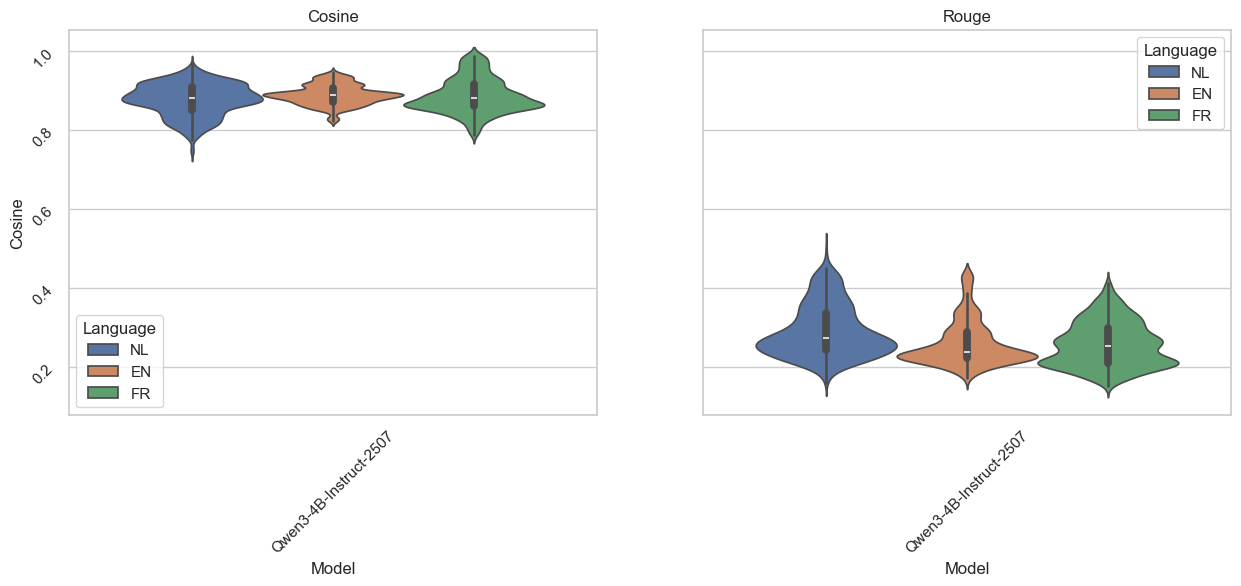

In [9]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]
fig, axs = plt.subplots(ncols=len(ys), figsize=(15,5), sharey=True)

# not between questions, each violin plot has 24 data points
for i in range(len(ys)):
    axs[i].tick_params(labelrotation=45)   
    axs[i].title.set_text(ys[i])
    seaborn.violinplot(x="Model", 
                       y=ys[i], 
                       hue="Language",
                       data=baseline_compare,
                       density_norm='count',
                       ax=axs[i])

TypeError: 'Axes' object is not subscriptable

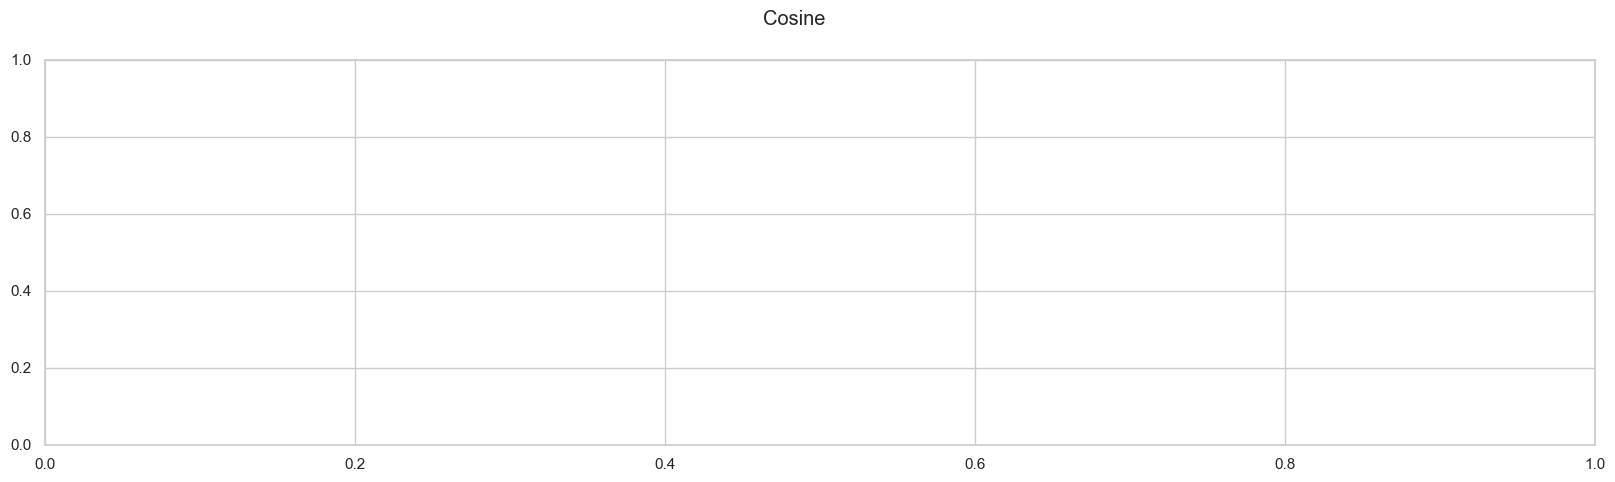

In [10]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]

# between questions, each violin plot only has 3 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(baseline_compare["Model"].unique()), figsize=(20,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in baseline_compare["Model"].unique():  
        axs[i].title.set_text(model)
        axs[i].tick_params(labelrotation=45)                    
        seaborn.violinplot(x ="Question", 
                           y=y, 
                           hue="Language",
                           data = baseline_compare[baseline_compare["Model"]==model],
                           density_norm='count',
                           ax=axs[i])
        i+=1
    plt.figure()

In [ ]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine"]

# between questions, each violin plot only has 3 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(lang_compare["Model"].unique())+2, figsize=(30,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in lang_compare["Model"].unique():  
        for b in [True, False]:
            axs[i].title.set_text(f"{model}_baseline{b}")
            axs[i].tick_params(labelrotation=45)                    
            seaborn.violinplot(x ="Question", 
                               y=y, 
                               hue="Language1-Language2",
                               data = lang_compare[(lang_compare["Model"]==model)&(lang_compare["fBaseline"]==b)],
                               density_norm='count',
                               ax=axs[i])
            i+=1
    plt.figure()

In [ ]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine"]

# not between questions, each violin plot has 24 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(lang_compare["Model"].unique()), figsize=(20,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in lang_compare["Model"].unique():  
        axs[i].title.set_text(f"{model}")
        axs[i].tick_params(labelrotation=45)                    
        seaborn.violinplot(x ="Language1-Language2", 
                           y=y, 
                           hue="fBaseline",
                           data = lang_compare[(lang_compare["Model"]==model)],
                           density_norm='count',
                           ax=axs[i])
        i+=1
    plt.figure()

## See data

In [ ]:
from datasets import load_from_disk, concatenate_datasets
import pickle
import json
from glob import glob

paths = glob("t0*")

In [ ]:
answers = [load_from_disk(x) for x in paths]
answers = concatenate_datasets(answers)
with open("question_map.pkl", 'rb') as f:
    question_map = pickle.load(f)
with open("params.json", 'r') as f:
    params = json.load(f)
answers = answers.add_column("question_mapped", [question_map[x] for x in answers["question"]])

In [ ]:
question_map

In [ ]:
answers = answers.to_pandas()

In [ ]:
answers["answers"][1][0]

In [ ]:
answers.to_csv("all_answers.csv", encoding="utf-8")

In [ ]:
all()